# EECE 6544 MiniProject #02: HealthGuard Insurance Pricing

 Majd Khalaf  


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

DATA_PATH = 'insurance.csv'
FIG_DIR = 'figures'
OUT_DIR = 'outputs'
RANDOM_STATE = 42

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (9, 5.5)
plt.rcParams['axes.grid'] = True

## 2. Load and profile the raw data

The dataset is loaded directly with `pandas.read_csv`. The raw dataframe is kept unchanged, and a separate copy is used for cleaning.

In [5]:
raw_df = pd.read_csv(DATA_PATH)

print('Shape:', raw_df.shape)
display(raw_df.head())

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
raw_df.info()
display(raw_df.describe().T)

for column in ['sex', 'smoker', 'region']:
    print()
    print(column, 'value counts')
    display(raw_df[column].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801



sex value counts


sex
male      676
female    662
Name: count, dtype: int64


smoker value counts


smoker
no     1064
yes     274
Name: count, dtype: int64


region value counts


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

## 3. Cleaning decisions and rationale


In [8]:
cleaned_df = raw_df.copy()

cleaned_df.columns = cleaned_df.columns.str.strip().str.lower().str.replace(' ', '_')

for column in ['sex', 'smoker', 'region']:
    cleaned_df[column] = cleaned_df[column].str.strip().str.lower()

for column in ['age', 'bmi', 'children', 'charges']:
    cleaned_df[column] = pd.to_numeric(cleaned_df[column], errors='coerce')

cleaned_df = cleaned_df.dropna()
cleaned_df = cleaned_df[cleaned_df['age'].between(18, 100)]
cleaned_df = cleaned_df[cleaned_df['bmi'].between(10, 80)]
cleaned_df = cleaned_df[cleaned_df['children'].between(0, 20)]
cleaned_df = cleaned_df[cleaned_df['charges'] > 0]
cleaned_df = cleaned_df[cleaned_df['sex'].isin(['female', 'male'])]
cleaned_df = cleaned_df[cleaned_df['smoker'].isin(['yes', 'no'])]
cleaned_df = cleaned_df[cleaned_df['region'].isin(['northeast', 'northwest', 'southeast', 'southwest'])]
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

cleaning_summary = pd.DataFrame({
    'Raw data': [len(raw_df), raw_df.isna().sum().sum(), raw_df.duplicated().sum()],
    'Cleaned data': [len(cleaned_df), cleaned_df.isna().sum().sum(), cleaned_df.duplicated().sum()]
}, index=['Rows', 'Missing values', 'Duplicate rows'])

display(cleaning_summary)
display(cleaned_df.head())

cleaned_df.to_csv(OUT_DIR + '/insurance_cleaned.csv', index=False)

,Raw data,Cleaned data
Rows,1338,1337
Missing values,0,0
Duplicate rows,1,0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 4. Pandas wrangling toolkit: 21 techniques

In [10]:
# 1. Create/copy a dataframe
tech_df = cleaned_df.head(20).copy()

# 2. Select columns
selected_columns = tech_df[['age', 'bmi', 'charges']]

# 3. Select rows with loc/iloc
selected_rows = tech_df.loc[0:4, ['age', 'smoker', 'charges']]

# 4. Filter/query rows
filtered_rows = tech_df.query("smoker == 'yes' and bmi >= 30")

# 5. Sort values
sorted_rows = tech_df.sort_values('charges', ascending=False)

# 6. Create a derived column with assign
assigned_df = tech_df.assign(charge_per_child=lambda d: d['charges'] / (d['children'] + 1))

# 7. Replace category values
replaced_df = tech_df.assign(sex=tech_df['sex'].replace({'female': 'F', 'male': 'M'}))

# 8. Rename columns
renamed_df = tech_df.rename(columns={'charges': 'annual_charges'})

# 9. Detect missing values on a deliberately messy sandbox copy
messy_df = tech_df.copy()
messy_df.loc[0, 'bmi'] = np.nan
messy_df.loc[1, 'region'] = pd.NA
missing_counts = messy_df.isna().sum()

# 10. Fill missing values
filled_df = messy_df.assign(
    bmi=messy_df['bmi'].fillna(messy_df['bmi'].median()),
    region=messy_df['region'].fillna(messy_df['region'].mode().iloc[0])
)

# 11. Drop rows with missing values
complete_case_df = messy_df.dropna()

# 12. Drop rows by an explicit condition
reasonable_bmi_df = tech_df.drop(index=tech_df.index[tech_df['bmi'] > 50])

# 13. Drop columns
reduced_df = tech_df.drop(columns=['sex'])

# 14. Drop duplicate rows
with_duplicate = pd.concat([tech_df, tech_df.iloc[[0]]], ignore_index=True)
deduplicated_df = with_duplicate.drop_duplicates()

# 15. Count categorical values
smoker_counts = tech_df['smoker'].value_counts()

# 16. Group data
grouped = cleaned_df.groupby('smoker', observed=True)

# 17. Aggregate several statistics
aggregated = grouped['charges'].agg(['count', 'mean', 'median', 'std'])

# 18. Apply/map a function
applied_df = tech_df.assign(
    bmi_class=tech_df['bmi'].apply(lambda value: 'BMI >= 30' if value >= 30 else 'BMI < 30')
)

# 19. Resample after creating a synthetic record date for technique demonstration
# The synthetic date is not used in modeling or interpreted as real time-series data.
resample_df = cleaned_df[['charges']].copy()
resample_df['record_date'] = pd.date_range('2022-01-01', periods=len(resample_df), freq='D')
monthly_resampled = resample_df.set_index('record_date')['charges'].resample('ME').mean()

# 20. Concatenate row partitions
first_half = cleaned_df.iloc[:len(cleaned_df)//2]
second_half = cleaned_df.iloc[len(cleaned_df)//2:]
concatenated_df = pd.concat([first_half, second_half], ignore_index=True)

# 21. Merge with a lookup table
region_lookup = pd.DataFrame({
    'region': ['northeast', 'northwest', 'southeast', 'southwest'],
    'market_label': ['Northeast Market', 'Northwest Market', 'Southeast Market', 'Southwest Market']
})
merged_df = cleaned_df.merge(region_lookup, on='region', how='left')

print('Selected rows:')
display(selected_rows)
print('Missing counts in sandbox data:')
display(missing_counts.to_frame('missing'))
print('Grouped/aggregated charges:')
display(aggregated)
print('Monthly resampling preview:')
display(monthly_resampled.head())
print(f'Concatenation restored all rows: {len(concatenated_df) == len(cleaned_df)}')
print('Merge preview:')
display(merged_df[['region', 'market_label']].head())

Selected rows:


,age,smoker,charges
0,19,yes,16884.92400
1,18,no,1725.55230
2,28,no,4449.46200
3,33,no,21984.47061
4,32,no,3866.85520


Missing counts in sandbox data:


,missing
age,0
sex,0
bmi,1
children,0
smoker,0
region,1
charges,0


Grouped/aggregated charges:


,count,mean,median,std
smoker,,,,
no,1063,8440.660307,7345.72660,5992.973800
yes,274,32050.231832,34456.34845,11541.547176


Monthly resampling preview:


record_date
2022-01-31    13847.201017
2022-02-28    17097.602800
2022-03-31    12590.003667
2022-04-30    13953.439462
2022-05-31    11914.084811
Freq: ME, Name: charges, dtype: float64

Concatenation restored all rows: True
Merge preview:


,region,market_label
0,southwest,Southwest Market
1,southeast,Southeast Market
2,southeast,Southeast Market
3,northwest,Northwest Market
4,northwest,Northwest Market


## 5. Feature engineering

In [12]:
analysis_df = cleaned_df.assign(
    smoker_binary=cleaned_df['smoker'].map({'no': 0, 'yes': 1}),
    bmi_category=pd.cut(
        cleaned_df['bmi'], bins=[0, 18.5, 25, 30, np.inf],
        labels=['Underweight', 'Healthy', 'Overweight', 'BMI >= 30'], right=False
    ),
    age_group=pd.cut(
        cleaned_df['age'], bins=[17, 25, 35, 45, 55, 65],
        labels=['18-25', '26-35', '36-45', '46-55', '56-64']
    ),
    charges_log=np.log1p(cleaned_df['charges'])
)

EXPENSIVE_THRESHOLD = cleaned_df['charges'].median()
analysis_df['expensive'] = (analysis_df['charges'] > EXPENSIVE_THRESHOLD).astype(int)

print(f'Median-based expensive-customer threshold: ${EXPENSIVE_THRESHOLD:,.2f}')
display(analysis_df.head())

Median-based expensive-customer threshold: $9,386.16


,age,sex,bmi,children,smoker,region,charges,smoker_binary,bmi_category,age_group,charges_log,expensive
0,19,female,27.900,0,yes,southwest,16884.92400,1,Overweight,18-25,9.734236,1
1,18,male,33.770,1,no,southeast,1725.55230,0,BMI >= 30,18-25,7.453882,0
2,28,male,33.000,3,no,southeast,4449.46200,0,BMI >= 30,26-35,8.400763,0
3,33,male,22.705,0,no,northwest,21984.47061,0,Healthy,26-35,9.998137,1
4,32,male,28.880,0,no,northwest,3866.85520,0,Overweight,26-35,8.260455,0


## 6. Exploratory data analysis

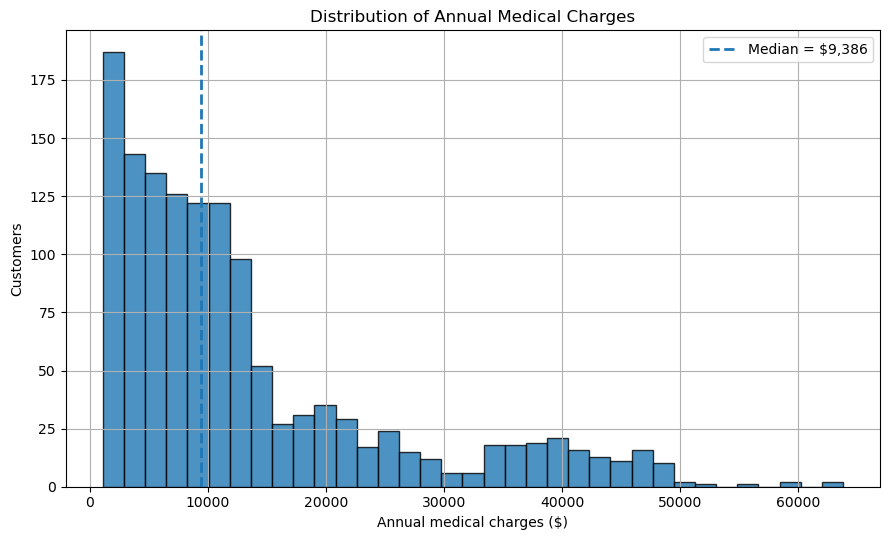

In [14]:
# Figure 1: Distribution of annual charges
plt.figure()
plt.hist(analysis_df['charges'], bins=35, edgecolor='black', alpha=0.8)
plt.axvline(EXPENSIVE_THRESHOLD, linestyle='--', linewidth=2, label=f'Median = ${EXPENSIVE_THRESHOLD:,.0f}')
plt.xlabel('Annual medical charges ($)')
plt.ylabel('Customers')
plt.title('Distribution of Annual Medical Charges')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '/01_charges_distribution.png', dpi=200)
plt.show()

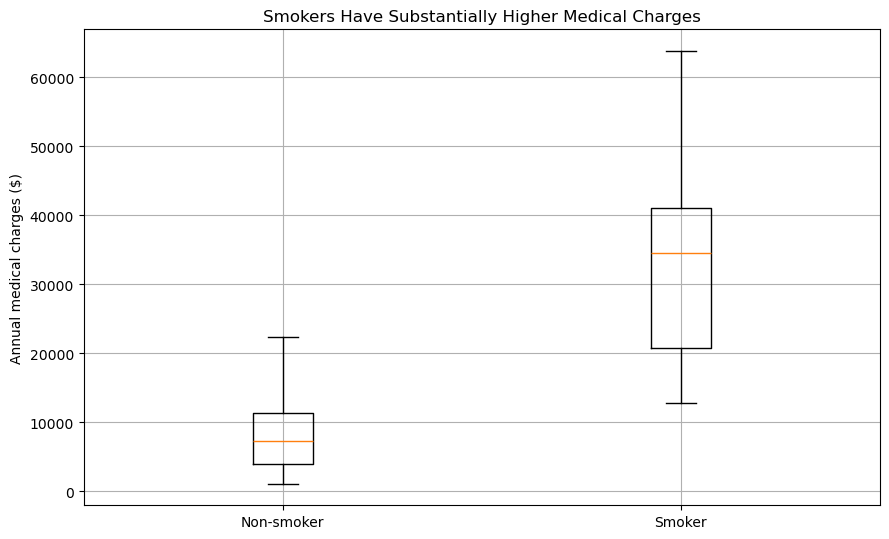

In [15]:
# Figure 2: Smoking status versus charges
non_smoker = analysis_df.loc[analysis_df['smoker'] == 'no', 'charges']
smoker = analysis_df.loc[analysis_df['smoker'] == 'yes', 'charges']
plt.figure()
plt.boxplot([non_smoker, smoker], tick_labels=['Non-smoker', 'Smoker'], showfliers=False)
plt.ylabel('Annual medical charges ($)')
plt.title('Smokers Have Substantially Higher Medical Charges')
plt.tight_layout()
plt.savefig(FIG_DIR + '/02_charges_by_smoking.png', dpi=200)
plt.show()

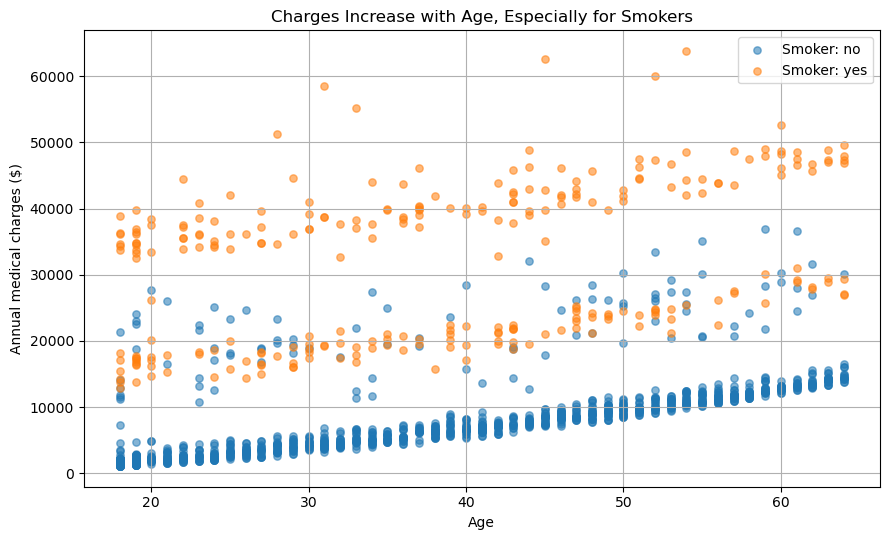

In [16]:
# Figure 3: Age versus charges, separated by smoking status
plt.figure()
for label, group in analysis_df.groupby('smoker', observed=True):
    plt.scatter(group['age'], group['charges'], alpha=0.55, s=28, label=f'Smoker: {label}')
plt.xlabel('Age')
plt.ylabel('Annual medical charges ($)')
plt.title('Charges Increase with Age, Especially for Smokers')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '/03_age_vs_charges.png', dpi=200)
plt.show()

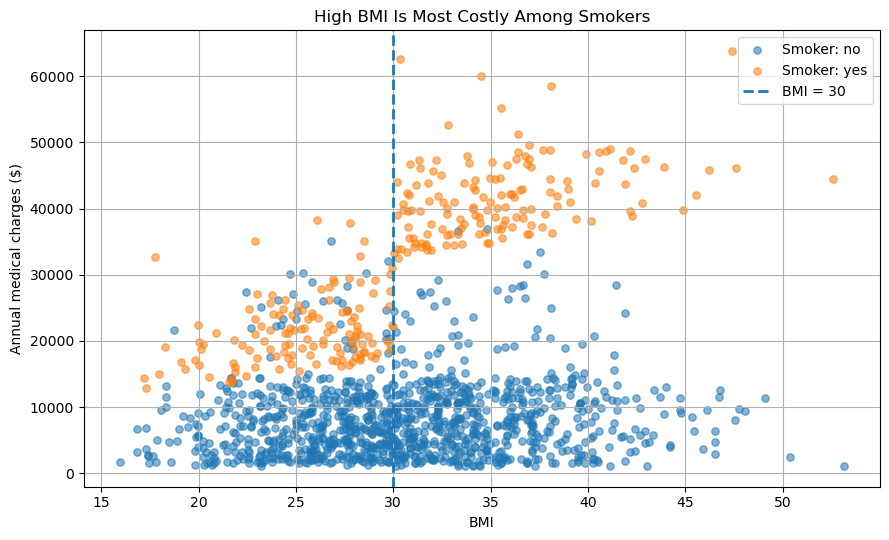

In [17]:
# Figure 4: BMI versus charges, separated by smoking status
plt.figure()
for label, group in analysis_df.groupby('smoker', observed=True):
    plt.scatter(group['bmi'], group['charges'], alpha=0.55, s=28, label=f'Smoker: {label}')
plt.axvline(30, linestyle='--', linewidth=2, label='BMI = 30')
plt.xlabel('BMI')
plt.ylabel('Annual medical charges ($)')
plt.title('High BMI Is Most Costly Among Smokers')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '/04_bmi_vs_charges.png', dpi=200)
plt.show()

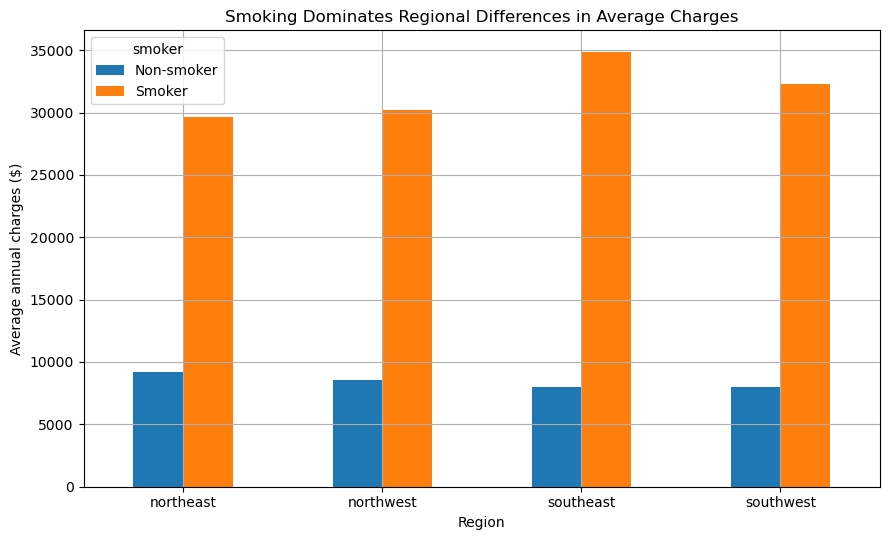

In [18]:
# Figure 5: Average charges by region and smoking status
region_smoker = analysis_df.pivot_table(
    index='region', columns='smoker', values='charges', aggfunc='mean'
).rename(columns={'no': 'Non-smoker', 'yes': 'Smoker'})
plt.figure()
region_smoker.plot(kind='bar', ax=plt.gca())
plt.xlabel('Region')
plt.ylabel('Average annual charges ($)')
plt.title('Smoking Dominates Regional Differences in Average Charges')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR + '/05_region_smoker_charges.png', dpi=200)
plt.show()

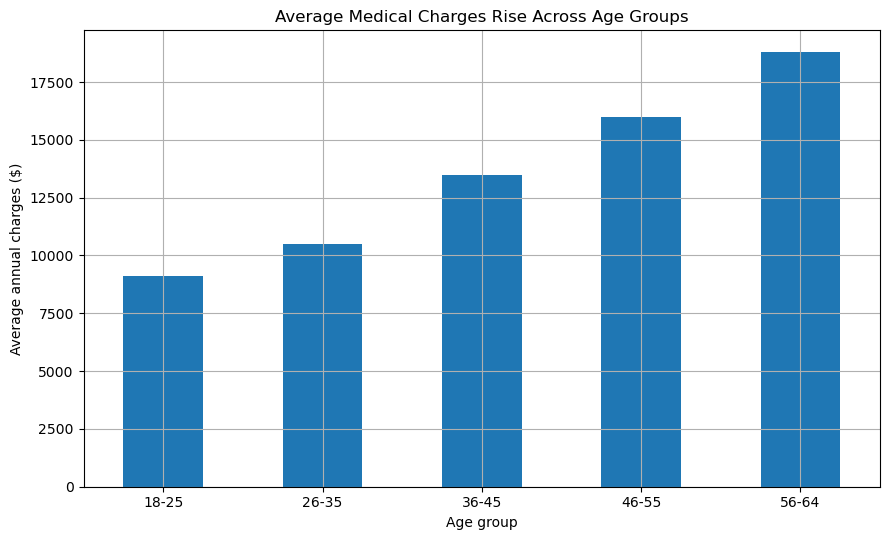

In [19]:
# Figure 6: Average charges by age group
age_group_charges = analysis_df.groupby('age_group', observed=True)['charges'].mean()
plt.figure()
age_group_charges.plot(kind='bar', ax=plt.gca())
plt.xlabel('Age group')
plt.ylabel('Average annual charges ($)')
plt.title('Average Medical Charges Rise Across Age Groups')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR + '/06_age_group_charges.png', dpi=200)
plt.show()

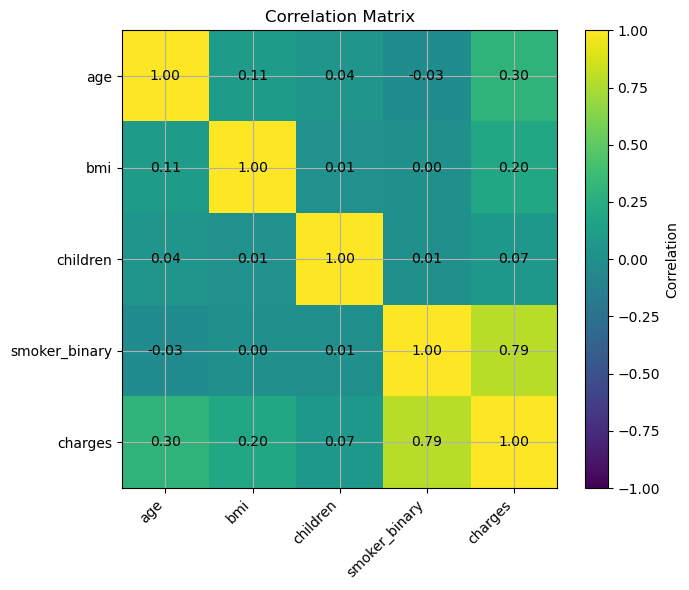

In [20]:
# Figure 7: Correlation matrix for numeric variables and encoded smoking status
corr_columns = ['age', 'bmi', 'children', 'smoker_binary', 'charges']
correlation_matrix = analysis_df[corr_columns].corr()
plt.figure(figsize=(7, 6))
image = plt.imshow(correlation_matrix, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(image, label='Correlation')
plt.xticks(range(len(corr_columns)), corr_columns, rotation=45, ha='right')
plt.yticks(range(len(corr_columns)), corr_columns)
for row in range(len(corr_columns)):
    for col in range(len(corr_columns)):
        plt.text(col, row, f'{correlation_matrix.iloc[row, col]:.2f}', ha='center', va='center')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR + '/07_correlation_matrix.png', dpi=200)
plt.show()

### EDA quantitative summaries

In [22]:
smoking_summary = analysis_df.groupby('smoker', observed=True)['charges'].agg(['count', 'mean', 'median'])
smoker_ratio = smoking_summary.loc['yes', 'mean'] / smoking_summary.loc['no', 'mean']

bmi_smoker_summary = analysis_df.assign(bmi_30_plus=analysis_df['bmi'] >= 30).groupby(
    ['smoker', 'bmi_30_plus'], observed=True
)['charges'].mean().unstack()

age_charge_corr = analysis_df['age'].corr(analysis_df['charges'])
bmi_charge_corr = analysis_df['bmi'].corr(analysis_df['charges'])
region_summary = analysis_df.groupby('region', observed=True)['charges'].mean().sort_values(ascending=False)

print(f'Smokers average {smoker_ratio:.2f}x the charges of non-smokers.')
print(f'Age-charge correlation: {age_charge_corr:.3f}')
print(f'BMI-charge correlation: {bmi_charge_corr:.3f}')
print('\nCharges by smoking status:')
display(smoking_summary)
print('Charges by smoking status and BMI threshold:')
display(bmi_smoker_summary)
print('Average charges by region:')
display(region_summary.to_frame('average_charges'))

Smokers average 3.80x the charges of non-smokers.
Age-charge correlation: 0.298
BMI-charge correlation: 0.198

Charges by smoking status:


,count,mean,median
smoker,,,
no,1063,8440.660307,7345.72660
yes,274,32050.231832,34456.34845


Charges by smoking status and BMI threshold:


bmi_30_plus,False,True
smoker,,
no,7977.029520,8855.531349
yes,21363.217016,41557.989840


Average charges by region:


,average_charges
region,
southeast,14735.411438
northeast,13406.384516
northwest,12450.840844
southwest,12346.937377


### EDA interpretation for the stakeholder

- **Smoking is the strongest observed cost driver.** Smoker charges form a separate, much higher-cost distribution.
- **Age has a clear positive relationship with charges.** Average charges rise steadily across age groups.
- **BMI matters nonlinearly and interacts with smoking.** BMI at or above 30 is associated with a particularly large increase among smokers, while the average difference among non-smokers is much smaller.
- **Region and sex have weaker raw effects.** Some group means differ, but these effects are much smaller than smoking and should not be interpreted causally without controlling for other attributes.
- **Charges are right-skewed.** A minority of very expensive customers drives the mean above the median, supporting both regression and median-based classification.

## 7. Regression: predict annual medical charges

The categorical columns are one-hot encoded once with `pd.get_dummies`. Numeric columns are scaled for Ridge, Lasso, polynomial regression, and SVR. Every model uses the same 80/20 train/test split.

In [25]:
X = pd.get_dummies(
    cleaned_df.drop(columns='charges'),
    drop_first=True,
    dtype=int
)
y = cleaned_df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

numeric_columns = ['age', 'bmi', 'children']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
display(X.head())

Training rows: 1069
Test rows: 268


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


In [26]:
regression_rows = []
regression_predictions = {}
regression_models = {}
polynomial_diagnostics = []


def save_regression_result(name, model, train_data, test_data):
    model.fit(train_data, y_train)
    prediction = model.predict(test_data)
    mse = mean_squared_error(y_test, prediction)

    regression_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, prediction),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_test, prediction)
    })

    regression_predictions[name] = prediction
    regression_models[name] = model


# 1. Simple Linear Regression
simple_model = LinearRegression()
save_regression_result(
    'Simple Linear Regression (smoker only)',
    simple_model,
    X_train[['smoker_yes']],
    X_test[['smoker_yes']]
)

# 2. Multiple Linear Regression
multiple_model = LinearRegression()
save_regression_result(
    'Multiple Linear Regression',
    multiple_model,
    X_train_scaled,
    X_test_scaled
)

# 3. Polynomial Regression, degrees 2 through 4
for degree in [2, 3, 4]:
    polynomial = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = polynomial.fit_transform(X_train_scaled)
    X_test_poly = polynomial.transform(X_test_scaled)

    model = LinearRegression()
    name = f'Polynomial Regression (degree {degree})'
    save_regression_result(name, model, X_train_poly, X_test_poly)

    train_prediction = model.predict(X_train_poly)
    test_prediction = regression_predictions[name]

    polynomial_diagnostics.append({
        'Degree': degree,
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, train_prediction)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, test_prediction)),
        'Train_R2': r2_score(y_train, train_prediction),
        'Test_R2': r2_score(y_test, test_prediction)
    })

# 4. Ridge Regression
ridge_search = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring='neg_root_mean_squared_error'
)
save_regression_result(
    'Ridge Regression',
    ridge_search,
    X_train_scaled,
    X_test_scaled
)

# 5. Lasso Regression
lasso_search = GridSearchCV(
    Lasso(max_iter=20000),
    {'alpha': [0.01, 0.1, 1, 10, 50, 100, 250, 500, 1000]},
    cv=5,
    scoring='neg_root_mean_squared_error'
)
save_regression_result(
    'Lasso Regression',
    lasso_search,
    X_train_scaled,
    X_test_scaled
)

# 6. Support Vector Regression with two kernels
charge_scaler = StandardScaler()
y_train_scaled = charge_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()

for kernel in ['linear', 'rbf']:
    model = SVR(kernel=kernel, C=10, epsilon=0.05)
    model.fit(X_train_scaled, y_train_scaled)

    scaled_prediction = model.predict(X_test_scaled)
    prediction = charge_scaler.inverse_transform(
        scaled_prediction.reshape(-1, 1)
    ).ravel()

    name = f'SVR ({kernel} kernel)'
    mse = mean_squared_error(y_test, prediction)

    regression_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, prediction),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_test, prediction)
    })

    regression_predictions[name] = prediction
    regression_models[name] = model

# 7. Decision Tree Regression
tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    {
        'max_depth': [2, 3, 4, 5, 6, 8, None],
        'min_samples_leaf': [1, 5, 10, 20]
    },
    cv=5,
    scoring='neg_root_mean_squared_error'
)
save_regression_result(
    'Decision Tree Regression',
    tree_search,
    X_train,
    X_test
)

regression_results = pd.DataFrame(regression_rows)
regression_results['Selected hyperparameters'] = ''
regression_results.loc[
    regression_results['Model'] == 'Ridge Regression',
    'Selected hyperparameters'
] = str(ridge_search.best_params_)
regression_results.loc[
    regression_results['Model'] == 'Lasso Regression',
    'Selected hyperparameters'
] = str(lasso_search.best_params_)
regression_results.loc[
    regression_results['Model'] == 'Decision Tree Regression',
    'Selected hyperparameters'
] = str(tree_search.best_params_)

regression_results = regression_results.sort_values(['RMSE', 'MAE']).reset_index(drop=True)
regression_results.to_csv(OUT_DIR + '/regression_model_comparison.csv', index=False)
display(regression_results)

,Model,MAE,MSE,RMSE,R2,Selected hyperparameters
0,Decision Tree Regression,2621.312405,1.888663e+07,4345.875200,0.897219,"{'max_depth': 4, 'min_samples_leaf': 5}"
1,Polynomial Regression (degree 2),2867.317439,2.158584e+07,4646.056793,0.882530,
2,SVR (rbf kernel),2312.581882,2.318947e+07,4815.544281,0.873803,
3,Polynomial Regression (degree 3),3048.863649,2.371953e+07,4870.269998,0.870918,
4,Multiple Linear Regression,4177.045561,3.547802e+07,5956.342894,0.806929,
5,Ridge Regression,4193.891909,3.566313e+07,5971.861741,0.805921,{'alpha': 1}
6,Lasso Regression,4223.716095,3.634105e+07,6028.354178,0.802232,{'alpha': 50}
7,Polynomial Regression (degree 4),3756.150028,3.669766e+07,6057.859428,0.800291,
8,SVR (linear kernel),3141.267964,3.918256e+07,6259.597483,0.786769,
9,Simple Linear Regression (smoker only),5830.635673,6.003930e+07,7748.503349,0.673266,


### Polynomial overfitting diagnostic

Increasing polynomial degree reduces training error, but degree 4 produces a much larger train-test gap and worse test performance. This is evidence of overfitting.

In [28]:
polynomial_diagnostics_df = pd.DataFrame(polynomial_diagnostics)
polynomial_diagnostics_df['RMSE_gap'] = (
    polynomial_diagnostics_df['Test_RMSE'] - polynomial_diagnostics_df['Train_RMSE']
)

polynomial_diagnostics_df.to_csv(
    OUT_DIR + '/polynomial_overfitting_diagnostic.csv',
    index=False
)

display(polynomial_diagnostics_df)

,Degree,Train_RMSE,Test_RMSE,Train_R2,Test_R2,RMSE_gap
0,2,4766.993578,4646.056793,0.834026,0.882530,-120.936785
1,3,4575.157161,4870.269998,0.847116,0.870918,295.112837
2,4,4274.363009,6057.859428,0.866558,0.800291,1783.496419


### Lasso feature elimination

In [30]:
best_lasso_model = lasso_search.best_estimator_

lasso_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_lasso_model.coef_
})

lasso_table['eliminated'] = lasso_table['coefficient'].abs() < 0.000001
lasso_table = lasso_table.sort_values(
    'coefficient',
    key=abs,
    ascending=False
)

lasso_table.to_csv(OUT_DIR + '/lasso_coefficients.csv', index=False)

print('Selected alpha:', lasso_search.best_params_['alpha'])
print('Features eliminated by Lasso:')
display(lasso_table[lasso_table['eliminated']])
print('All Lasso coefficients:')
display(lasso_table)

Selected alpha: 50
Features eliminated by Lasso:


,feature,coefficient,eliminated
3,sex_male,-0.0,True
5,region_northwest,0.0,True


All Lasso coefficients:


,feature,coefficient,eliminated
4,smoker_yes,22737.682985,False
0,age,3436.996911,False
1,bmi,1818.083330,False
2,children,595.806372,False
6,region_southeast,-152.516179,False
7,region_southwest,-28.666455,False
3,sex_male,-0.000000,True
5,region_northwest,0.000000,True


### Decision-tree visualization

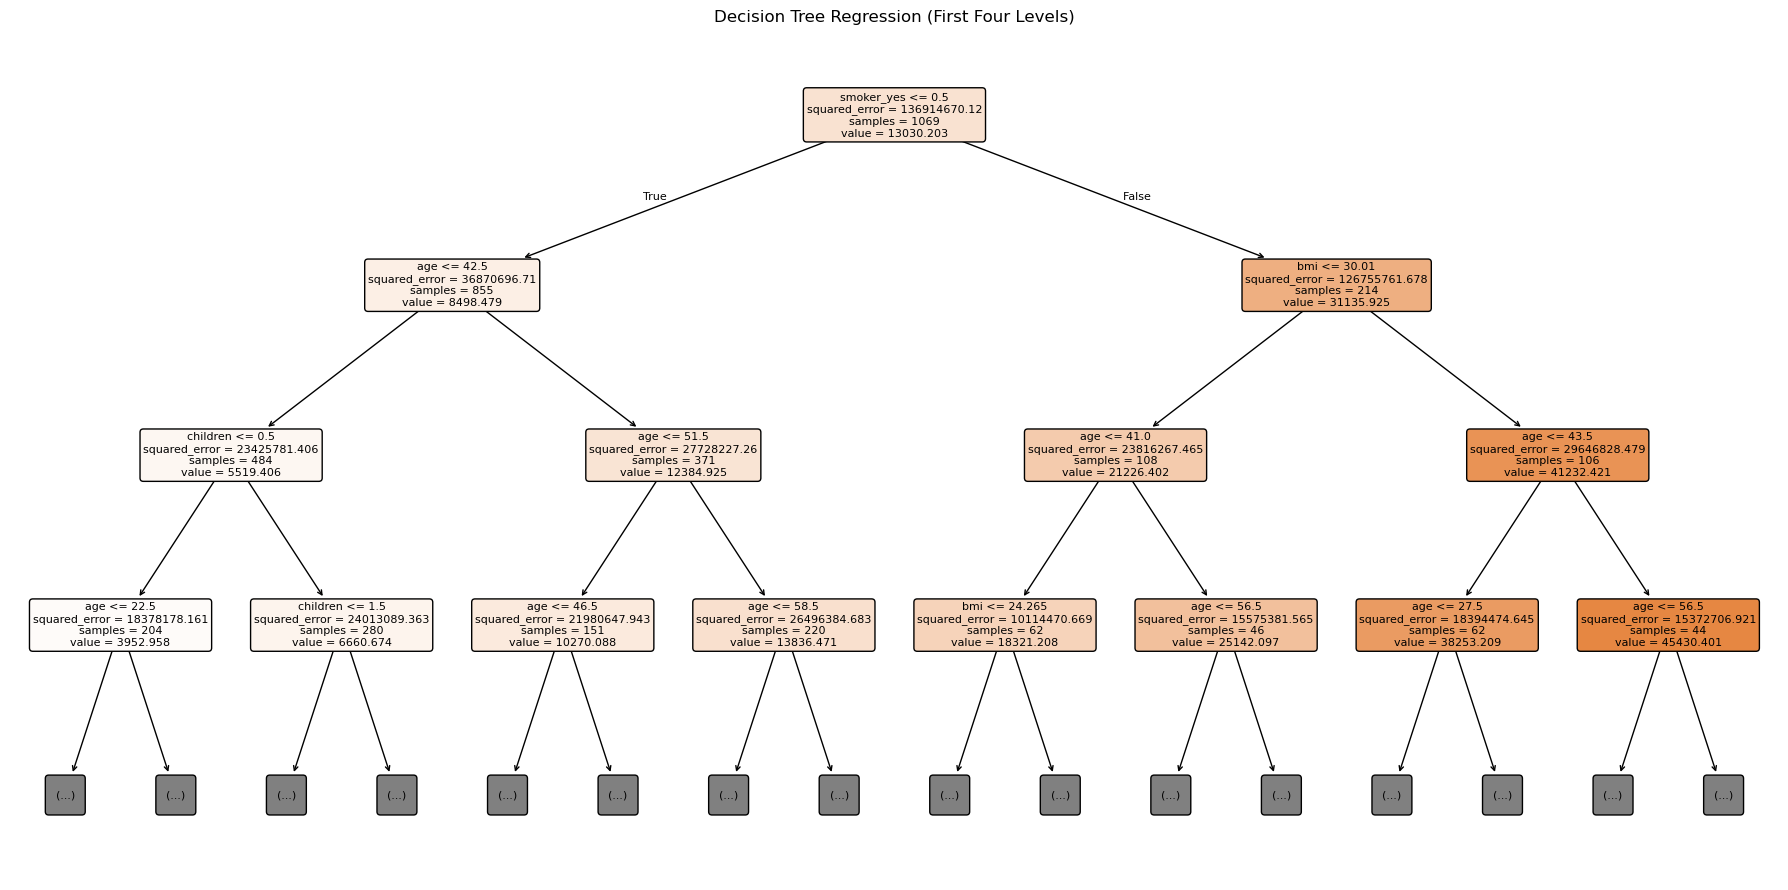

In [32]:
best_tree_model = tree_search.best_estimator_

plt.figure(figsize=(18, 9))
plot_tree(
    best_tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Decision Tree Regression (First Four Levels)')
plt.tight_layout()
plt.savefig(FIG_DIR + '/08_decision_tree_regression.png', dpi=200)
plt.show()

### Recommended regression model and held-out performance

Recommended regression model: Decision Tree Regression


,value
Model,Decision Tree Regression
MAE,2621.312405
MSE,18886631.250029
RMSE,4345.8752
R2,0.897219
Selected hyperparameters,"{'max_depth': 4, 'min_samples_leaf': 5}"


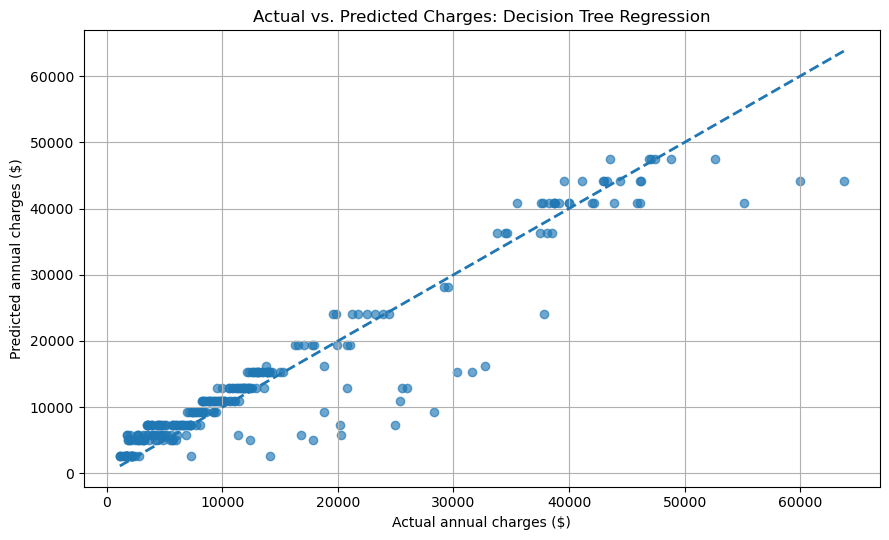

In [34]:
best_regression_name = regression_results.iloc[0]['Model']
best_regression_metrics = regression_results.iloc[0]
best_regression_prediction = regression_predictions[best_regression_name]

print('Recommended regression model:', best_regression_name)
display(best_regression_metrics.to_frame('value'))

plt.figure()
plt.scatter(y_test, best_regression_prediction, alpha=0.65)
minimum = min(y_test.min(), best_regression_prediction.min())
maximum = max(y_test.max(), best_regression_prediction.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle='--', linewidth=2)
plt.xlabel('Actual annual charges ($)')
plt.ylabel('Predicted annual charges ($)')
plt.title('Actual vs. Predicted Charges: ' + best_regression_name)
plt.tight_layout()
plt.savefig(FIG_DIR + '/09_best_regression_actual_vs_predicted.png', dpi=200)
plt.show()

**Regression recommendation:** The cross-validated decision tree is recommended because it has the lowest test RMSE and MAE and the highest test R² in this comparison. Its limited depth and minimum-leaf constraint capture the strong nonlinear smoking/BMI interactions while controlling tree complexity. The degree-2 polynomial and RBF SVR are competitive alternatives, but the tree is easier to explain to the stakeholder.

## 8. Classification: flag expensive customers

A customer is labeled expensive when annual charges exceed the median of the cleaned dataset. The same one-hot-encoded predictors are used for classification.

In [37]:
y_class = (cleaned_df['charges'] > EXPENSIVE_THRESHOLD).astype(int)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_class
)

classification_scaler = StandardScaler()
Xc_train_scaled = Xc_train.copy()
Xc_test_scaled = Xc_test.copy()

Xc_train_scaled[numeric_columns] = classification_scaler.fit_transform(
    Xc_train[numeric_columns]
)
Xc_test_scaled[numeric_columns] = classification_scaler.transform(
    Xc_test[numeric_columns]
)

logistic_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
knn_model = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [5, 9, 15]},
    cv=3,
    scoring='f1'
)
svc_model = SVC(
    kernel='rbf',
    C=10,
    probability=True,
    random_state=RANDOM_STATE
)
classification_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {
        'max_depth': [3, 4, 5, 6],
        'min_samples_leaf': [5, 10, 20]
    },
    cv=3,
    scoring='f1'
)
forest_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=3,
    random_state=RANDOM_STATE
)

models = [
    ('Logistic Regression', logistic_model, Xc_train_scaled, Xc_test_scaled),
    ('K-Nearest Neighbors', knn_model, Xc_train_scaled, Xc_test_scaled),
    ('Support Vector Classifier (RBF)', svc_model, Xc_train_scaled, Xc_test_scaled),
    ('Decision Tree Classifier', classification_tree, Xc_train, Xc_test),
    ('Random Forest Classifier', forest_model, Xc_train, Xc_test)
]

classification_rows = []
classification_scores = {}
classification_predictions = {}

for name, model, train_data, test_data in models:
    model.fit(train_data, yc_train)
    prediction = model.predict(test_data)
    probability = model.predict_proba(test_data)[:, 1]

    classification_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(yc_test, prediction),
        'Precision': precision_score(yc_test, prediction),
        'Recall': recall_score(yc_test, prediction),
        'F1': f1_score(yc_test, prediction),
        'ROC_AUC': roc_auc_score(yc_test, probability)
    })

    classification_scores[name] = probability
    classification_predictions[name] = prediction

classification_results = pd.DataFrame(classification_rows)
classification_results['Selected hyperparameters'] = ''
classification_results.loc[
    classification_results['Model'] == 'K-Nearest Neighbors',
    'Selected hyperparameters'
] = str(knn_model.best_params_)
classification_results.loc[
    classification_results['Model'] == 'Decision Tree Classifier',
    'Selected hyperparameters'
] = str(classification_tree.best_params_)

classification_results = classification_results.sort_values(
    ['F1', 'ROC_AUC'],
    ascending=False
).reset_index(drop=True)

classification_results.to_csv(
    OUT_DIR + '/classification_model_comparison.csv',
    index=False
)

display(classification_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Selected hyperparameters
0,Support Vector Classifier (RBF),0.940299,0.960938,0.917910,0.938931,0.961350,
1,Random Forest Classifier,0.940299,0.968254,0.910448,0.938462,0.947761,
2,Decision Tree Classifier,0.925373,0.952381,0.895522,0.923077,0.941858,"{'max_depth': 6, 'min_samples_leaf': 5}"
3,Logistic Regression,0.906716,0.897810,0.917910,0.907749,0.952941,
4,K-Nearest Neighbors,0.861940,0.929204,0.783582,0.850202,0.923173,{'n_neighbors': 9}


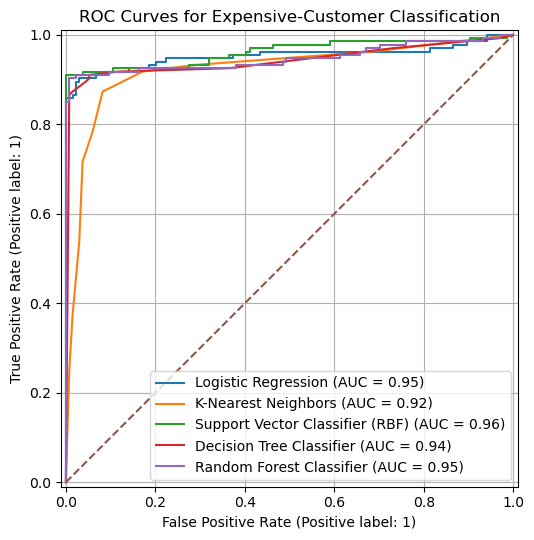

In [38]:
plt.figure()
axis = plt.gca()

for name, probability in classification_scores.items():
    RocCurveDisplay.from_predictions(
        yc_test,
        probability,
        name=name,
        ax=axis
    )

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curves for Expensive-Customer Classification')
plt.tight_layout()
# plt.savefig(FIG_DIR + '/10_classification_roc_curves.png', dpi=200)
plt.show()

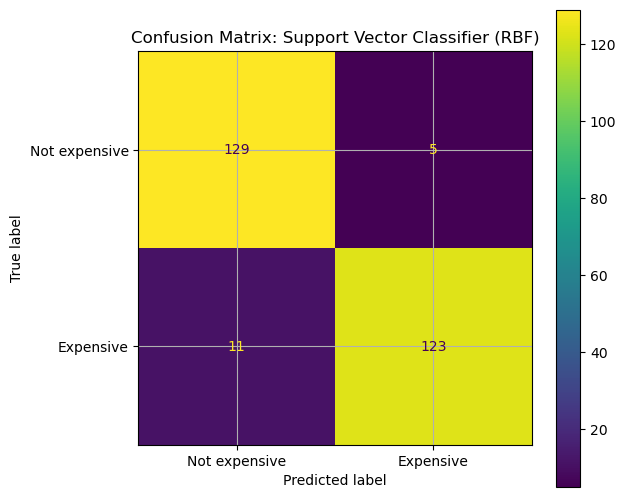

Recommended classifier: Support Vector Classifier (RBF)


,value
Model,Support Vector Classifier (RBF)
Accuracy,0.940299
Precision,0.960938
Recall,0.91791
F1,0.938931
ROC_AUC,0.96135
Selected hyperparameters,


In [39]:
best_classification_name = classification_results.iloc[0]['Model']
best_classification_prediction = classification_predictions[best_classification_name]

matrix = confusion_matrix(yc_test, best_classification_prediction)

plt.figure(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=['Not expensive', 'Expensive']
).plot(ax=plt.gca(), values_format='d')

plt.title('Confusion Matrix: ' + best_classification_name)
plt.tight_layout()
plt.savefig(FIG_DIR + '/11_best_classifier_confusion_matrix.png', dpi=200)
plt.show()

print('Recommended classifier:', best_classification_name)
display(classification_results.iloc[0].to_frame('value'))

**Classification recommendation:** The RBF support-vector classifier is recommended because it provides the strongest combination of F1, recall, and ROC-AUC in the held-out test set. Recall is especially important because a false negative means failing to flag a genuinely expensive customer. A random forest is a strong alternative when feature importance and tree-based explanations are preferred.

## 9. Final stakeholder recommendation

### Pricing estimate
Use the tuned **Decision Tree Regression** model as the academic prototype for annual charge estimation. It performed best on the held-out test set and naturally captures nonlinear interactions such as smoking combined with high BMI.

### Expensive-customer flag
Use the **RBF Support Vector Classifier** to flag customers above the median charge threshold. It achieved the best balance of F1, recall, and ROC-AUC in the comparison.

### Business interpretation
Smoking status is the clearest cost separator. Age adds a steady increase in expected cost, while BMI becomes especially important for smokers. Region and sex carry much weaker raw signals. HealthGuard should avoid translating these associations directly into production prices without actuarial, legal, and fairness review.

### Limitations and next steps

- The dataset contains only 1,337 unique records and lacks diagnoses, plan design, utilization history, provider network, and calendar time.
- The test results come from one fixed held-out split; repeated cross-validation or an external validation dataset would provide stronger evidence.
- The median threshold is specific to this sample and should be recalculated for the company's own portfolio.
- Sensitive or protected attributes require fairness analysis and compliance review before deployment.
- Medical charges are not necessarily identical to insurer-paid cost, future loss, or an actuarially fair premium.

## 10. Reproducibility checklist

- Raw and cleaned data are stored separately.
- Random state is fixed at 42.
- The same train/test split is used for every regression model.
- One-hot encoding is performed once with `pd.get_dummies`.
- Numeric columns are scaled only for models that benefit from scaling.
- Ridge, Lasso, KNN, and decision-tree settings are tuned using cross-validation.

In [43]:
project_summary = pd.Series({
    'Raw rows': len(raw_df),
    'Cleaned rows': len(cleaned_df),
    'Duplicates removed': len(raw_df) - len(cleaned_df),
    'Expensive threshold': EXPENSIVE_THRESHOLD,
    'Smoker cost ratio': smoker_ratio,
    'Best regression model': best_regression_name,
    'Best regression RMSE': best_regression_metrics['RMSE'],
    'Best regression R2': best_regression_metrics['R2'],
    'Best classification model': best_classification_name,
    'Best classification F1': classification_results.iloc[0]['F1'],
    'Best classification ROC_AUC': classification_results.iloc[0]['ROC_AUC']
})

project_summary.to_csv(OUT_DIR + '/project_summary.csv', header=['Value'])
display(project_summary.to_frame('Value'))

,Value
Raw rows,1338
Cleaned rows,1337
Duplicates removed,1
Expensive threshold,9386.1613
Smoker cost ratio,3.797124
Best regression model,Decision Tree Regression
Best regression RMSE,4345.8752
Best regression R2,0.897219
Best classification model,Support Vector Classifier (RBF)
Best classification F1,0.938931
